# Visualisations

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mplsoccer import Pitch
import requests
from ipywidgets import Dropdown, interact
from IPython.display import display, HTML
import os
import time
# Global variables
BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
PITCH_X, PITCH_Y = 120, 80


## Read Data

In [6]:
def read_json(url: str):
    """Read JSON from a URL (slightly more robust than pd.read_json)."""
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()


def load_competitions():
    url = f"{BASE}/competitions.json"
    comps = pd.DataFrame(read_json(url))
    return comps


def load_matches(competition_id: int, season_id: int):
    url = f"{BASE}/matches/{competition_id}/{season_id}.json"
    matches = pd.DataFrame(read_json(url))
    return matches


def load_events(match_id: int):
    url = f"{BASE}/events/{match_id}.json"
    events = read_json(url)

    # Flatten nested dicts into columns like type.name, team.name, etc.
    df = pd.json_normalize(events, sep=".")
    df["match_id"] = match_id
    return df

def pick_season_competition(comps: pd.DataFrame, preferred_name=None, preferred_season="2015/2016"):
    # Check if the competition takes place over two years
    if "/" in preferred_season:
        
        # Select competition for a given season
        first_year = preferred_season.split("/")[0]
        second_year = preferred_season.split("/")[1]
        
        # season_name varies => catches the required season
        mask = comps["season_name"].astype(str).str.contains(first_year, na=False) & comps["season_name"].astype(str).str.contains(second_year, na=False)
    
    else:
        year = preferred_season
        mask = comps["season_name"].astype(str).str.contains(year, na=False)
        
    c = comps[mask].copy()

    if preferred_name is not None:
        c2 = c[c["competition_name"].eq(preferred_name)]
        if len(c2):
            return c2.iloc[0]

    if len(c) == 0:
        raise ValueError("No season found in competitions.json for this open dataset.")
    return c.iloc[0]


def load_all_season_data(competition_id: int, season_id: int, sleep: float = 0.1) -> dict:
    """
    Load ALL match events for a season ONCE.
    Returns dict with all data needed for any analysis.
    """
    matches = load_matches(competition_id, season_id)
    
    # Get all teams
    teams = set()
    for _, m in matches.iterrows():
        teams.add(m["home_team"]["home_team_name"])
        teams.add(m["away_team"]["away_team_name"])
    teams = sorted(list(teams))
    
    print(f"Loading {len(matches)} matches for {len(teams)} teams...")
    
    # Load all events ONCE
    all_events = {}
    for i, mid in enumerate(matches["match_id"].unique()):
        if i % 10 == 0:
            print(f"  Loading match {i+1}/{len(matches)}...")
        all_events[int(mid)] = load_events(int(mid))
        time.sleep(sleep)
    
    print("Data loaded")
    
    return {
        "matches": matches,
        "teams": teams,
        "events": all_events,  # All events stored in a dict keyed by match_id
    }


In [46]:
def build_events_df(all_events: dict, matches: pd.DataFrame) -> pd.DataFrame:
    """Concatenate match event tables into one season-level DataFrame."""
    events_df = pd.concat(all_events.values(), ignore_index=True)

    # Add x,y coords safely, even when some location values are missing or incorrectly formatted
    if "location" in events_df.columns:
        location_values = [
            loc if isinstance(loc, (list, tuple)) and len(loc) == 2 else [np.nan, np.nan]
            for loc in events_df["location"].tolist()
        ]
        coords = pd.DataFrame(location_values, index=events_df.index, columns=["x", "y"])
        events_df = pd.concat([events_df, coords], axis=1)

    # Rename columns for easier access
    events_df["event_type"] = events_df["type.name"]
    events_df["team_name"] = events_df["team.name"]
    events_df["player_name"] = events_df["player.name"]
    events_df["match_date"] = events_df["match_id"].map(matches.set_index("match_id")["match_date"])

    match_index = matches.set_index("match_id")
    home_team_names = match_index["home_team"].apply(lambda d: d.get("home_team_name") if isinstance(d, dict) else np.nan)
    away_team_names = match_index["away_team"].apply(lambda d: d.get("away_team_name") if isinstance(d, dict) else np.nan)
    events_df["home_team"] = events_df["match_id"].map(home_team_names)
    events_df["away_team"] = events_df["match_id"].map(away_team_names)

    # Simplify outcome columns if they exist
    if "shot.outcome.name" in events_df.columns:
        events_df["shot_outcome"] = events_df["shot.outcome.name"]
    if "pass.outcome.name" in events_df.columns:
        events_df["pass_outcome"] = events_df["pass.outcome.name"]

    return events_df


comps = load_competitions()
target = ["FIFA World Cup", "2022"]
season = pick_season_competition(comps, preferred_name=target[0], preferred_season=target[1])
print("Selected season:", season["competition_name"], season["season_name"])
season_data = load_all_season_data(season["competition_id"], season["season_id"], sleep=0.05)

events_df = build_events_df(season_data["events"], season_data["matches"])
print("Events loaded:", events_df.shape)
# print(events_df[["match_id", "event_type", "team_name", "player_name", "x", "y"]].head())


    competition_id  ...             match_available
0                9  ...  2024-09-28T20:46:38.893391
1                9  ...  2024-05-19T11:11:14.192381
2             1267  ...  2026-05-12T21:18:08.827431
3               16  ...  2026-05-15T15:54:04.598614
4               16  ...  2024-02-13T02:35:28.134882
..             ...  ...                         ...
75              35  ...  2026-04-11T12:48:10.012987
76              53  ...  2026-04-27T22:02:42.690507
77              53  ...  2026-05-05T03:03:04.199896
78              72  ...  2026-05-03T13:51:31.021141
79              72  ...  2026-05-15T15:31:40.299642

[80 rows x 12 columns]
Selected season: 1. Bundesliga 2015/2016
Loading 34 matches for 18 teams...
  Loading match 1/34...
  Loading match 11/34...
  Loading match 21/34...
  Loading match 31/34...
Data loaded!
Events loaded: (115240, 148)
   match_id   event_type         team_name      player_name     x     y
0   3890563  Starting XI  Bayer Leverkusen              NaN   N

## Plot distribution of different comps

### All comps

In [106]:
# Confusion matrix for competitions and season 
seasons = comps['season_name'].unique()
competitions = comps['competition_name'].unique()

# Create Confusion Matrix
big_cm = pd.crosstab(
    comps['competition_name'], 
    comps['season_name'], 
    rownames=['Competition'], 
    colnames=['Season'], 
    margins=False, 
    # margins_name='Total'
    )
# Add colours and plot 
# plt.figure(figsize=(12, 8))
# sns.heatmap(big_cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
# plt.title('Confusion Matrix of all Competitions and Seasons', fontsize=16)
# plt.tight_layout()
# plt.show()

### Top 5 Leagues

In [105]:
top5 = ["Premier League", "La Liga", "1. Bundesliga", "Serie A", "Ligue 1"]
filtered_comps = comps[comps['competition_name'].isin(top5)]
filtered_cm = pd.crosstab(
    filtered_comps['competition_name'], 
    filtered_comps['season_name'], 
    rownames=['Competition'], 
    colnames=['Season'], 
    margins=False, 
    # margins_name='Total'
    )

# Add colours and plot
# plt.figure(figsize=(12, 8))
# sns.heatmap(filtered_cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
# plt.title("Top 5 Leagues by Season")
# plt.xlabel("Season")
# plt.ylabel("Competition")
# plt.tight_layout()
# plt.show()

### Internationals

In [104]:
# Filter out competitions across two years (2015/2016, 2016/2017, etc.)
filtered_international_comps = comps[~comps['season_name'].str.contains("/")]

# Remove american leagues that take place in the same year (2024)
american_leagues = ["Major League Soccer", "Liga MX", "NWSL", "North American League"]

filtered_international_comps = filtered_international_comps[~filtered_international_comps['competition_name'].isin(american_leagues)]
filtered_international_cm = pd.crosstab(
    filtered_international_comps['competition_name'], 
    filtered_international_comps['season_name'], 
    rownames=['Competition'], 
    colnames=['Season'], 
    margins=False, 
    # margins_name='Total'
    )

# Add colours and plot
# plt.figure(figsize=(12, 8))
# sns.heatmap(filtered_international_cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
# plt.title("International Competitions")
# plt.xlabel("Year")
# plt.ylabel("Competition")
# plt.tight_layout()
# plt.show()


## Player visualisations

In [32]:
def get_player_data(event_data, match_id=None, player_name=None):
    """Return all events for a specific player, optionally filtered to one match."""
    event_data = event_data.copy()

    # Filter for the specific match if match_id is provided
    if match_id is not None:
        event_data = event_data.loc[event_data["match_id"].eq(match_id)].copy()

    # Group events by player_name, then filter for the specific player
    # player_name = event_data["player_name"].dropna().astype(str).unique()[0]
    player_events = event_data.loc[event_data["player_name"].eq(player_name)].copy()
    print("Shape:", player_events.shape)
    return player_events

def get_team_names(event_data):
    """Return a list of unique team names in the event data."""
    return sorted(event_data["team_name"].dropna().astype(str).unique().tolist())

def get_team_players(event_data, team_name):
    """Return a list of unique player names for a specific team that have played in any games."""
    return sorted(event_data.loc[event_data["team_name"] == team_name, "player_name"].dropna().unique().tolist())

def get_matches_by_team(event_data, team_name):
    """Return a list of unique match IDs for a specific team."""
    return sorted(event_data.loc[event_data["team_name"] == team_name, "match_id"].dropna().unique().tolist())

def get_matches_by_player(event_data, player_name):
    """Return a list of unique match IDs for a specific player."""
    return sorted(event_data.loc[event_data["player_name"] == player_name, "match_id"].dropna().unique().tolist())

def get_player_names(event_data):
    """Return a list of unique player names in the event data."""
    return sorted(event_data["player_name"].dropna().astype(str).unique().tolist())

In [33]:
def update_player_dropdown(*args):
    """Update the player dropdown and show the players as a list/table."""
    selected_team = team_dropdown.value
    player_names = get_team_players(events_df, selected_team)

    player_dropdown.options = player_names
    if player_names:
        player_dropdown.value = player_names[0]


def player_display(player_name):
    """Show the player event data in a compact table."""
    player_data = events_df[events_df['player_name'] == player_name]
    display(HTML(player_data.to_html(index=False)))


# Create dropdown choice for available teams
team_names = get_team_names(events_df)
team_dropdown = Dropdown(
    options=team_names,
    description='Select Team:',
    value=team_names[0]
)

player_dropdown = Dropdown(
    options=get_team_players(events_df, team_names[0]),
    description='Select Player:'
)

team_dropdown.observe(update_player_dropdown, names='value')

display(team_dropdown)
display(player_dropdown)

Dropdown(description='Select Team:', options=('Argentina', 'Australia', 'Belgium', 'Brazil', 'Cameroon', 'Cana…

Dropdown(description='Select Player:', options=('Alejandro Darío Gómez', 'Alexis Mac Allister', 'Cristian Gabr…

### Dimensionality Reduction

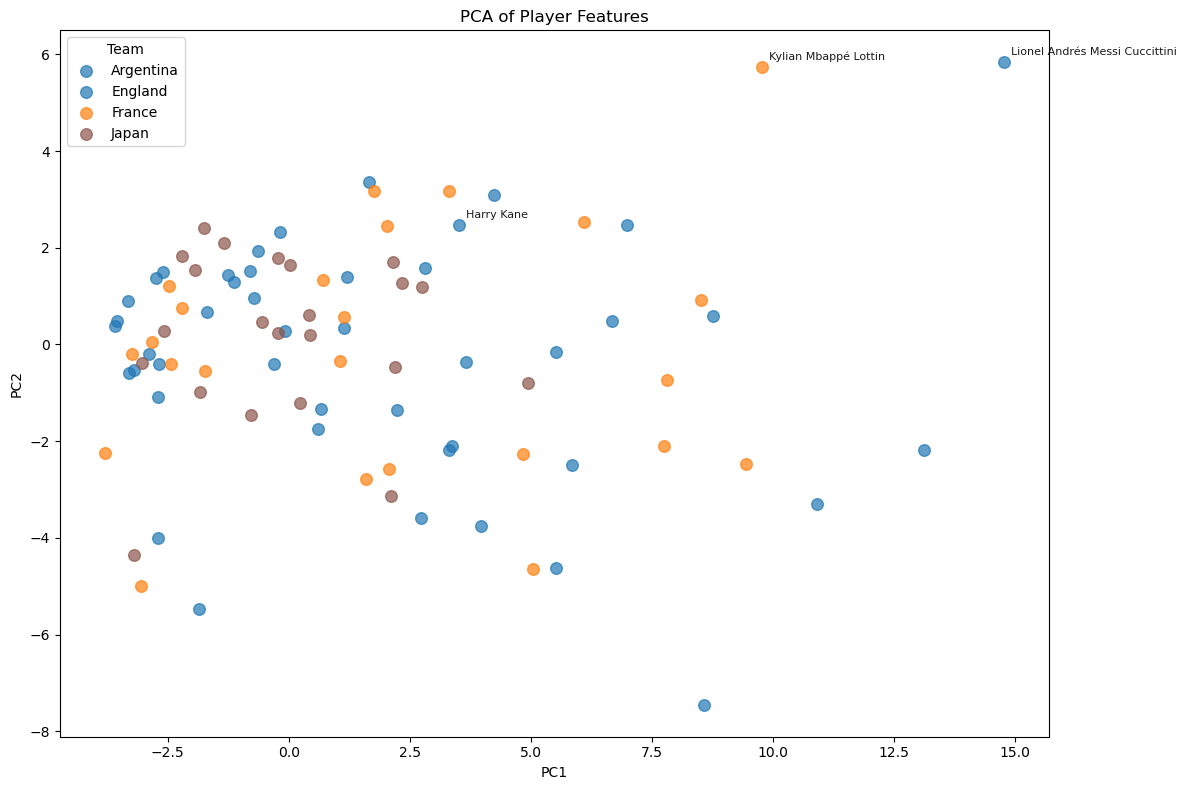

In [ ]:
# Build a player-indexed event structure and a PCA-ready feature matrix

def build_player_event_data(event_data: pd.DataFrame):
    """Return a dict of player -> DataFrame of that player's events."""

    if "player_name" not in event_data.columns:
        event_data["player_name"] = event_data.get("player.name", pd.Series([np.nan] * len(event_data))).fillna("Unknown")

    event_data = event_data.dropna(subset=["player_name"])

    player_data = {
        player_key: player_events.copy()
        for player_key, player_events in event_data.groupby("player_name", sort=True)
    }

    return player_data

if "player_data" not in globals():
    player_data = build_player_event_data(events_df)

if not os.path.exists("player_data.csv"):
    player_df = pd.DataFrame(index=player_data.keys())
    player_df.to_csv("player_data.csv", index=True)
else:
    player_df = pd.read_csv("player_data.csv", index_col=0)

player_feature_matrix = player_df.copy()

player_team_lookup = {}
for player_name, events in player_data.items():
    team_names = events["team_name"].dropna().astype(str)
    if not team_names.empty:
        player_team_lookup[player_name] = team_names.mode().iloc[0]
    else:
        player_team_lookup[player_name] = "Unknown"

player_feature_matrix["team_name"] = [
    player_team_lookup.get(player_name, "Unknown")
    for player_name in player_feature_matrix.index
]

player_feature_matrix["avg_x"] = [events["x"].mean() if "x" in events.columns else np.nan for events in player_data.values()]
player_feature_matrix["avg_y"] = [events["y"].mean() if "y" in events.columns else np.nan for events in player_data.values()]
player_feature_matrix["std_x"] = [events["x"].std() if "x" in events.columns else np.nan for events in player_data.values()]
player_feature_matrix["std_y"] = [events["y"].std() if "y" in events.columns else np.nan for events in player_data.values()]

# Add counts for each event type seen in the competition
for event_type in sorted(events_df["event_type"].dropna().astype(str).unique()):
    player_feature_matrix[event_type] = [
        int((events.get("event_type", pd.Series([np.nan] * len(events))) == event_type).sum())
        for events in player_data.values()
    ]

player_feature_matrix = player_feature_matrix.fillna(0)

# Scale features before dimensionality reduction
scaler = StandardScaler()
player_features_scaled = scaler.fit_transform(player_feature_matrix.drop(columns=["team_name"]))

# Fit PCA on the player feature matrix
pca = PCA(n_components=2)
player_pca = pca.fit_transform(player_features_scaled)

player_pca_df = pd.DataFrame(
    player_pca,
    index=player_feature_matrix.index,
    columns=["PC1", "PC2"],
)
player_pca_df["team_name"] = player_feature_matrix["team_name"].values

team_names = sorted(player_pca_df["team_name"].dropna().astype(str).unique())
palette = sns.color_palette("tab10", n_colors=max(len(team_names), 1))
team_colours = dict(zip(team_names, palette))
teams_to_include = [
    "Japan", "France", "Argentina", "England", 
    "Morocco", "Spain", "Brazil", "Germany", 
    "Ecuador", "Iran", "Ghana", "Costa Rica",
    "Portugal"
]

fig, ax = plt.subplots(figsize=(12, 8))
for team_name in team_names:
    if team_name in teams_to_include:
        team_points = player_pca_df[player_pca_df["team_name"] == team_name]
        ax.scatter(
            team_points["PC1"],
            team_points["PC2"],
            alpha=0.7,
            s=70,
            c=[team_colours[team_name]],
            label=team_name,
        )

players_to_label = ["Lionel Andrés Messi Cuccittini","Harry Kane", "Kylian Mbappé Lottin", "Cristiano Ronaldo"]  
players_to_label = [name for name in players_to_label if name in player_pca_df.index]

for player_name in players_to_label:
    point = player_pca_df.loc[player_name]
    ax.annotate(
        player_name,
        (point["PC1"], point["PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA of Player Features")
ax.legend(title="Team", loc="best")
plt.tight_layout()
plt.show()


## Event visualisations

Helper functions

### Event Types

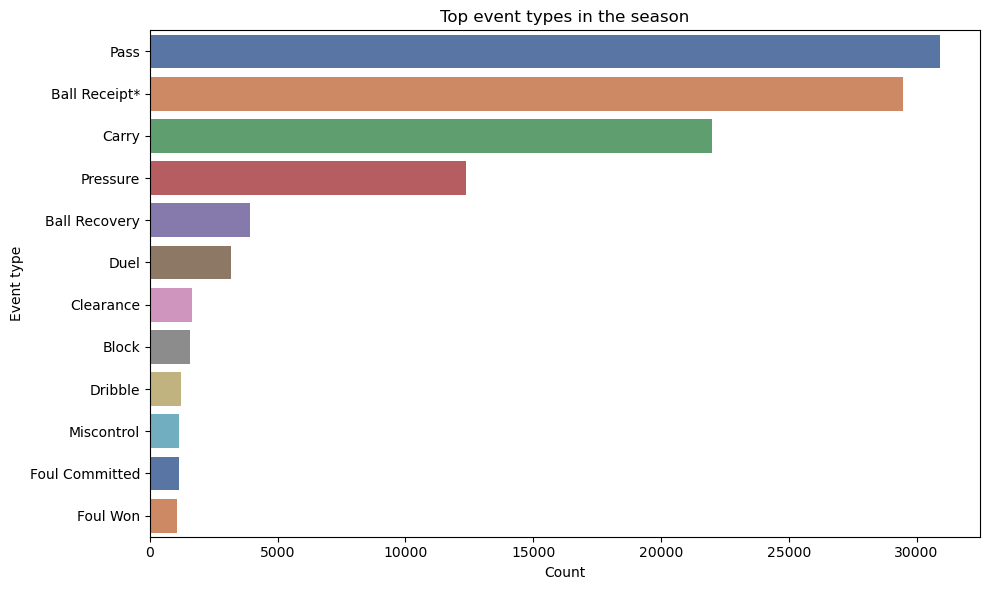

In [95]:

# Plot event type frequencies
plt.figure(figsize=(10, 6))
count_series = events_df["event_type"].value_counts().nlargest(12)
sns.barplot(x=count_series.values, y=count_series.index, hue=count_series.index, palette="deep")
plt.title("Top event types in the season")
plt.xlabel("Count")
plt.ylabel("Event type")
plt.tight_layout()

### Shooting and Passing

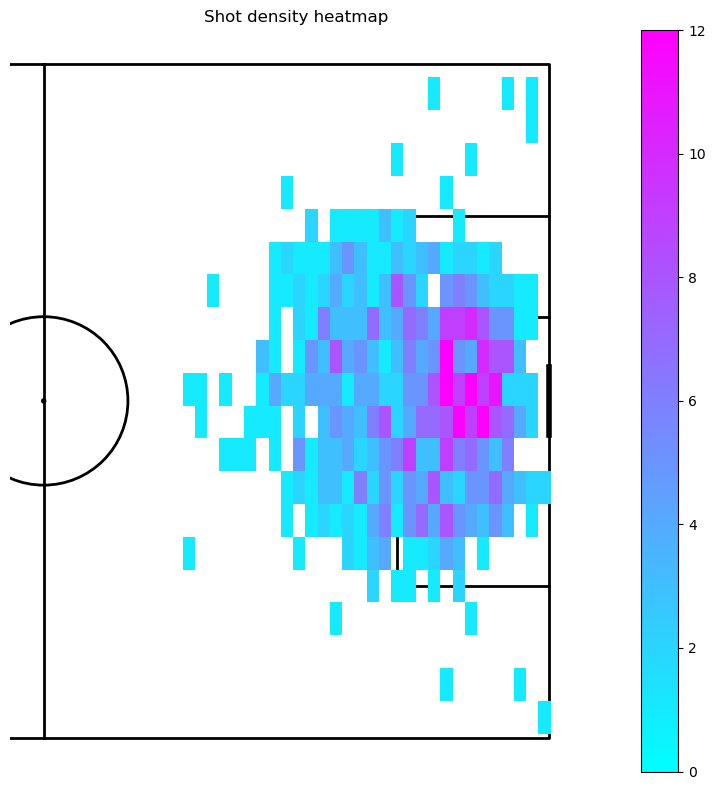

In [101]:
# Get shots events and append xG values
shots = events_df[events_df["event_type"] == "Shot"].copy()
shots = shots.dropna(subset=["x", "y"])
shots["xg"] = shots.get("shot.statsbomb_xg", pd.Series(0, index=shots.index)).fillna(0)

# Heatmap of shot density
fig, ax = plt.subplots(figsize=(12, 8))
draw_pitch(ax)
sns.histplot(
    data=shots,
    x="x",
    y="y",
    bins=(30, 20),
    pmax=0.9,
    cmap="cool",
    cbar=True,
    ax=ax,
)
ax.set_title("Shot density heatmap")
plt.tight_layout()

# # Example pass summary
# passes = events_df[events_df["event_type"] == "Pass"].copy()
# pass_summary = (
#     passes.groupby(["player_name", "pass.recipient.name"])
#     .size()
#     .reset_index(name="pass_count")
#     .sort_values("pass_count", ascending=False)
#     .head(10)
# )
# print("Top 10 pass combinations")
# print(pass_summary)
# pass_summary = pass_summary.rename(columns={"pass.recipient.name": "recipient_name"})
# # Create new column for combined player names
# pass_summary["player_combination"] = pass_summary["player_name"] + " -> " + pass_summary["recipient_name"]
# plt.figure(figsize=(10, 6))
# sns.barplot(data=pass_summary, x="pass_count", y="player_combination", hue="pass_count", palette="deep")
# plt.show()